<font size="6"><center style="color:#1B4F72"><br/>
Técnicas de Simulación</center></font>
<font size="4"><center style="color:#1B4F72"><br/>
Máster en Ingeniería Matemática</center></font>

<font size="5"><center><span style="color:#117864">***Nombre y Apellidos: Siria Catherine Iñiguez Brito***</span></center></font>

<font size="5"><center><span style="color:#1B4F72">***Práctica 1: Generadores de números pseudoaleatorios***</span></center></font>

### Importamos las librerías necesarias

In [1]:
import numpy as np
import pandas as pd
from math import sin, cos, sqrt, log, exp, pi
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as sp
from scipy import stats
from scipy.stats import shapiro, norm
from statsmodels.sandbox.stats.runs import runstest_1samp

In [2]:
# 1. Definición de la Paleta
PALETA = {
    'principal': '#2E4053',   # Azul Medianoche
    'secundario': '#5DADE2',  # Azul Acero
    'teorico': '#E74C3C',     # Rojo Coral
    'fondo': '#F4F6F7',       # Gris claro
    'texto': '#1B2631',       # Negro Azulado
    'rejilla': '#D5DBDB'      # Gris medio
}

# 2. Configuración Global de Estilo
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': PALETA['fondo'],
    'axes.edgecolor': PALETA['rejilla'],
    'axes.labelcolor': PALETA['texto'],
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'xtick.color': PALETA['texto'],
    'ytick.color': PALETA['texto'],
    'grid.color': 'white',
    'grid.linestyle': '-',
    'font.family': 'sans-serif'
})

### Valores de los parámetros para el método congruencial

Considerad los siguientes valores para los parámetros en el método congruencial:  
* m=2**(31)-1
* a=16807
* b=0  

y la semilla inicial en todos los casos será:  
* x0=123456789

In [3]:
m=2**(31)-1
a=16807
b=0
x0=123456789

## 1. Método congruencial.

In [4]:
# Definimos la funcion congruencial
def fCongruencial(x, a, b, m):
  return  (x*a + b) % m

# Definimos funcion para obtener N numero pseudoaleatorios U(0,1)
def fUniformeN(x, a, b, m, N):
  i = 0
  datos_u = []

  while i < N:
      x = fCongruencial(x, a, b, m)
      datos_u.append(x/m)
      i += 1

  return datos_u

## 2. Generar una distribución triangular:
(con parámetros a elegir)
* Utilizando método basado en la inversa de la función de distribución.
* Y basado en el método de rechazo.   

<font size="1">Sugerencia: si os resulta más cómodo, hacerlo a mano y adjuntar una foto.</font>

## 3. Box-Müller.
Generar 1000 números pseudoaleatorios por el coseno y 1000 por el seno.
Verificar con los indicadores estadísticos que consideres, contrastes y representación gráfica que efectivamente los números generados se distribuyen como una Normal(0,1).

In [5]:
# Función Box-Muller
def fBoxMuller(u_lista):
    u = np.array(u_lista)
    if len(u) % 2 != 0:
        u = u[:-1]

    u1 = u[0::2]
    u2 = u[1::2]

    term_radial = np.sqrt(-2 * np.log(u1))
    argumento_trig = 2 * np.pi * u2

    z_cos = term_radial * np.cos(argumento_trig)
    z_sen = term_radial * np.sin(argumento_trig)

    return z_cos, z_sen

# Función auxiliar para mostrar métricas
def mostrar_resultados(nombre, datos):
    media = np.mean(datos)
    var_s = np.var(datos)
    var_i = np.var(datos, ddof=1)

    print(f"Métricas para la Normal del {nombre}:")
    print(f"  mean    = {media:.8f}")
    print(f"  S^2_n   = {var_s:.6f}")
    print(f"  S^2_n-1 = {var_i:.6f}")
    print(f"  Valores iniciales: {datos[0]:.9f}, {datos[1]:.9f}, {datos[2]:.9f}...")
    print("-" * 45)

# Generación de Datos
N_sim = 200
x0 = 123456789
u_lista = fUniformeN(x0, a, b, m, N_sim)
z_cos, z_sen = fBoxMuller(u_lista)

# Ejecución de los resultados
print("=" * 45)
print(f"{'RESULTADOS BOX-MULLER':^45}")
print("=" * 45)
mostrar_resultados("Coseno (X)", z_cos)
mostrar_resultados("Seno (Y)", z_sen)

            RESULTADOS BOX-MULLER            
Métricas para la Normal del Coseno (X):
  mean    = 0.02737136
  S^2_n   = 1.079609
  S^2_n-1 = 1.090514
  Valores iniciales: 1.679040257, -0.566059812, 1.212934217...
---------------------------------------------
Métricas para la Normal del Seno (Y):
  mean    = -0.12201765
  S^2_n   = 1.040119
  S^2_n-1 = 1.050626
  Valores iniciales: -0.472768800, -0.231124131, 0.535037137...
---------------------------------------------


## 4. Método Marsaglia
Generar 1000 pares de números pseudoaleatorios Normal(0,1).

In [6]:
# Funcion de Marsaglia
def fMarsaglia(n_objetivo, x, a, b, m):
    x1_lista = []
    x2_lista = []
    x_curr = x
    intentos = 0

    while (len(x1_lista) + len(x2_lista)) < n_objetivo:
        intentos += 1

        # Generamos u1 y u2
        x_curr = (a * x_curr + b) % m
        u1 = x_curr / m

        x_curr = (a * x_curr + b) % m
        u2 = x_curr / m

        # Paso 2
        v1 = 2 * u1 - 1
        v2 = 2 * u2 - 1
        R2 = v1**2 + v2**2

        # Paso 3: Criterio (R2 > 1)
        if R2 > 1 or R2 == 0:
            continue

        # Paso 4
        y_factor = np.sqrt((-2 * np.log(R2)) / R2)
        x1_lista.append(v1 * y_factor)
        x2_lista.append(v2 * y_factor)

    return np.array(x1_lista), np.array(x2_lista), intentos


# Parametros
n_norm_objetivo = 200
x1_res, x2_res, total_it = fMarsaglia(n_norm_objetivo, x0, a, b, m)

# Función para imprimir
def imprimir_control_marsaglia(nombre, datos):
    print(f"Indicadores para {nombre}:")
    print(f"  Media (x_bar) = {np.mean(datos):.7f}")
    print(f"  S^2_n         = {np.var(datos):.7f}")
    print(f"  S^2_n-1       = {np.var(datos, ddof=1):.7f}")
    print(f"  u1, u2, u3... = {', '.join([f'{val:.8f}' for val in datos[:3]])}")
    print("-" * 50)

# Resultados
print("=" * 55)
print(f"{'RESULTADOS MARSAGLIA':^55}")
print("=" * 55)

imprimir_control_marsaglia("Secuencia X (x1)", x1_res)
imprimir_control_marsaglia("Secuencia Y (x2)", x2_res)


                 RESULTADOS MARSAGLIA                  
Indicadores para Secuencia X (x1):
  Media (x_bar) = 0.2159052
  S^2_n         = 0.7075141
  S^2_n-1       = 0.7146607
  u1, u2, u3... = 1.24295692, -0.13445768, -0.30786186
--------------------------------------------------
Indicadores para Secuencia Y (x2):
  Media (x_bar) = -0.1732801
  S^2_n         = 0.9229105
  S^2_n-1       = 0.9322328
  u1, u2, u3... = 0.23272421, -0.68882581, -0.49533180
--------------------------------------------------


## 5. Box-Müller antitéticas

In [7]:
def fBoxMullerAntitetico(u_lista):
    u = np.array(u_lista)
    if len(u) % 2 != 0:
        u = u[:-1]

    # Creamos el conjunto antitético
    u_anti = 1 - u

    u1 = u_anti[0::2]
    u2 = u_anti[1::2]

    # Lógica de Box-Muller
    term_radial = np.sqrt(-2 * np.log(u1))
    argumento_trig = 2 * np.pi * u2

    z_cos_anti = term_radial * np.cos(argumento_trig)
    z_sen_anti = term_radial * np.sin(argumento_trig)

    return z_cos_anti, z_sen_anti

Correlación en X: 0.5845
Correlación en Y: -0.6193


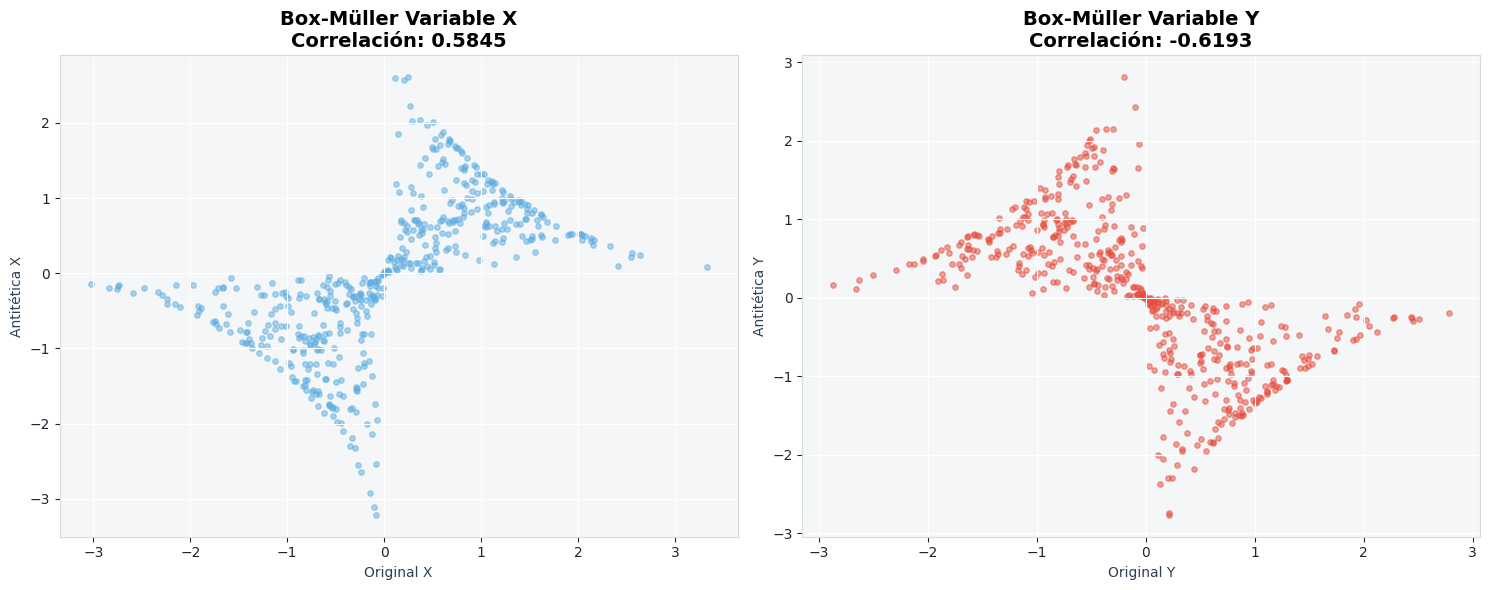

In [8]:
# Generación y cálculo
u_lista = fUniformeN(x0, a, b, m, 1000)
z_cos, z_sen = fBoxMuller(u_lista)
z_cos_anti, z_sen_anti = fBoxMullerAntitetico(u_lista)

corr_x = np.corrcoef(z_cos, z_cos_anti)[0, 1]
corr_y = np.corrcoef(z_sen, z_sen_anti)[0, 1]
print(f"Correlación en X: {corr_x:.4f}")
print(f"Correlación en Y: {corr_y:.4f}")

# Visualización
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Subplot 1: Variable X (Coseno)
ax1.scatter(z_cos, z_cos_anti, alpha=0.5, color=PALETA['secundario'], s=15, label='Pares (X, X_a)')
ax1.set_title(f"Box-Müller Variable X\nCorrelación: {corr_x:.4f}")
ax1.set_xlabel("Original X", color=PALETA['principal'])
ax1.set_ylabel("Antitética X", color=PALETA['principal'])
ax1.grid(True, color='white')

# Subplot 2: Variable Y (Seno)
ax2.scatter(z_sen, z_sen_anti, alpha=0.5, color=PALETA['teorico'], s=15, label='Pares (Y, Y_a)')
ax2.set_title(f"Box-Müller Variable Y\nCorrelación: {corr_y:.4f}")
ax2.set_xlabel("Original Y", color=PALETA['principal'])
ax2.set_ylabel("Antitética Y", color=PALETA['principal'])
ax2.grid(True, color='white')

fig.patch.set_facecolor('white')
plt.tight_layout()
plt.show()

# Análisis de la Correlación en el Método de Box-Müller Antitético

Al implementar la técnica de **variables antitéticas** en el método de Box-Müller, generamos pares de variables normales $(X, Y)$ y sus versiones antitéticas $(X_a, Y_a)$ a partir del complementario de las uniformes: $U = 1 - U$.

Tras analizar los resultados experimentales (**$\rho_X = 0.5845$** y **$\rho_Y = -0.6193$**), se confirma una asimetría crítica en la eficacia del método debido a las propiedades trigonométricas.

### 1. Ineficacia y Correlación Positiva en X (Coseno)
Para la variable $X$, la versión antitética utiliza $\cos(2\pi(1 - U))$. Por identidad trigonométricas del coseno:
$$\cos(2\pi - \theta) = \cos(\theta)$$

Nuestros resultados muestran una **correlación de $0.5845$**. Al no invertirse el signo de la función, la variable original y la antitética conservan la misma polaridad en la mayoría de los casos. Esto se traduce visualmente en el **gráfico azul**, donde los puntos se concentran en los cuadrantes I y III.
Esta correlación positiva es ineficiente para la reducción de varianza, ya que el promedio de los pares no tiende a estabilizarse hacia la media con la rapidez deseada.

### 2. Éxito y Reducción de Varianza en Y (Seno)
La variable $Y$ presenta una **correlación negativa de $-0.6193$**. Esto ocurre porque el seno es una función impar en este intervalo:
$$\sin(2\pi - \theta) = -\sin(\theta)$$

En este caso, el signo **sí se invierte**. Cuando $Y$ es positivo, su pareja antitética $Y_a$ tiende a ser negativa. Esta inversión de signos es fundamental porque genera una correlación negativa, la cual actúa como un sistema de compensación automática donde los errores por exceso de una variable se anulan con los errores por defecto de su pareja. En términos estadísticos, esto significa que el estimador de la media muestral ($\bar{Y} = \frac{Y + Y_a}{2}$) se vuelve mucho más robusto; mientras que en una simulación estándar los valores fluctúan libremente, aquí la correlación negativa obliga a los datos a converger hacia el valor esperado con mayor rapidez

## 6. Marsaglia antitéticas

In [9]:
def fMarsagliaAntitetico(n_objetivo, x, a, b, m):
    x1_lista = []
    x2_lista = []
    x_curr = x
    intentos = 0

    while (len(x1_lista) + len(x2_lista)) < n_objetivo:
        intentos += 1

        # Generamos u1 y u2 originales
        x_curr = (a * x_curr + b) % m
        u1 = x_curr / m

        x_curr = (a * x_curr + b) % m
        u2 = x_curr / m

        # --- CAMBIO ANTITÉTICO ---
        # Sustituimos u por (1 - u)
        u1_anti = 1 - u1
        u2_anti = 1 - u2

        # Paso 2 con las variables antitéticas
        v1 = 2 * u1_anti - 1
        v2 = 2 * u2_anti - 1

        R2 = v1**2 + v2**2

        # Paso 3: Criterio de rechazo
        if R2 > 1 or R2 == 0:
            continue

        # Paso 4
        y_factor = np.sqrt((-2 * np.log(R2)) / R2)
        x1_lista.append(v1 * y_factor)
        x2_lista.append(v2 * y_factor)

    return np.array(x1_lista), np.array(x2_lista), intentos

Correlación para el primer par (X1): -1.0000
Correlación para el segundo par (X2): -1.0000


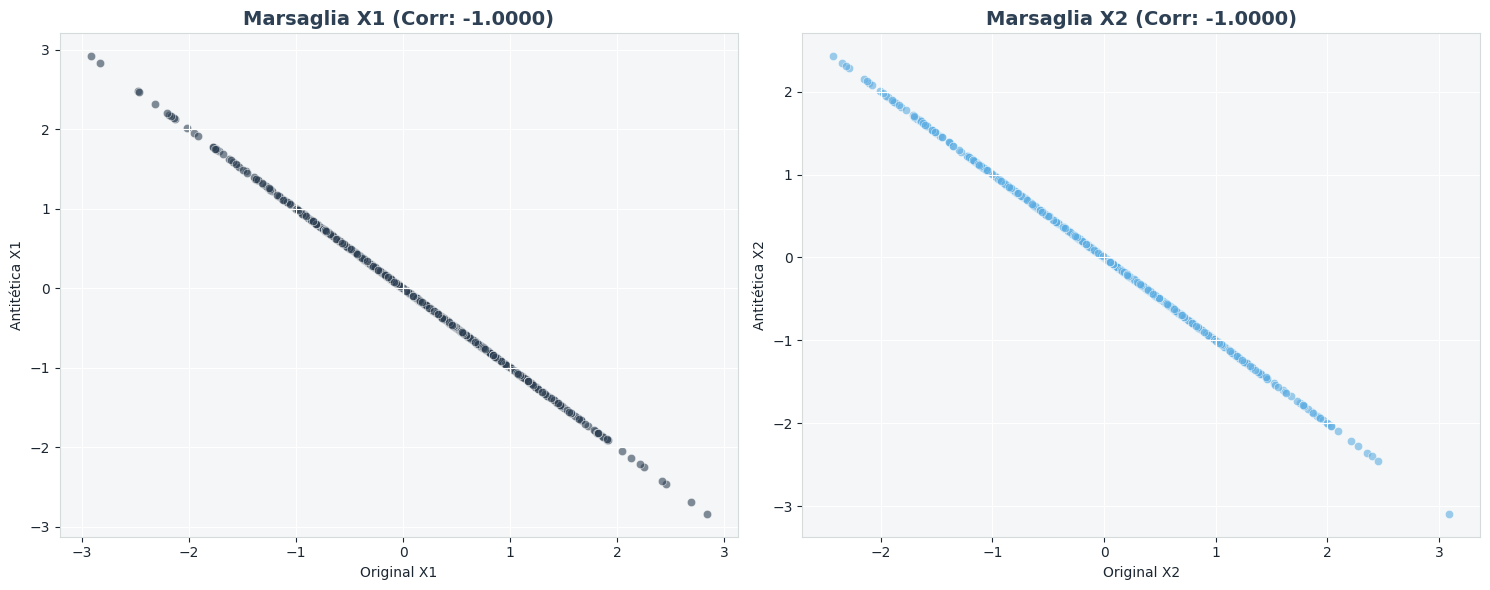

In [10]:
x_orig, y_orig, _ = fMarsaglia(1000, x0, a, b, m)
x_ant, y_ant, _ = fMarsagliaAntitetico(1000, x0, a, b, m)

corr_x1 = np.corrcoef(x_orig, x_ant)[0, 1]
corr_x2 = np.corrcoef(y_orig, y_ant)[0, 1]

print(f"Correlación para el primer par (X1): {corr_x1:.4f}")
print(f"Correlación para el segundo par (X2): {corr_x2:.4f}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Gráfico para X1
ax1.scatter(x_orig, x_ant, alpha=0.6, color=PALETA['principal'], edgecolors='white', linewidth=0.5)
ax1.set_title(f"Marsaglia X1 (Corr: {corr_x1:.4f})", color=PALETA['principal'])
ax1.set_xlabel("Original X1")
ax1.set_ylabel("Antitética X1")
ax1.grid(True)

# Gráfico para X2
ax2.scatter(y_orig, y_ant, alpha=0.6, color=PALETA['secundario'], edgecolors='white', linewidth=0.5)
ax2.set_title(f"Marsaglia X2 (Corr: {corr_x2:.4f})", color=PALETA['principal'])
ax2.set_xlabel("Original X2")
ax2.set_ylabel("Antitética X2")
ax2.grid(True)

plt.tight_layout()
plt.show()

# Análisis de la Correlación en el Método de Marsaglia Antitético
Los resultados obtenidos muestran una **correlación negativa perfecta (-1.0000)** tanto para el primer par de variables ($X_1$) como para el segundo ($X_2$). Al aplicar la transformación antitética $U_{anti} = 1 - U$ sobre los valores generados por el método de Marsaglia, se logra invertir simétricamente la posición de las variables normales resultantes respecto a su media. Los diagramas de dispersión reflejan una alineación lineal exacta con pendiente negativa, lo que confirma que el uso de estas variables inducirá una reducción máxima de la varianza en las estimaciones de Monte Carlo, cumpliendo así con el objetivo teórico de la técnica de reducción de varianza.

## 7. t-Student

## 8. Generar 1000 muestras de tamaño 20 de la Normal:
$N(\mu=7,\sigma=2)$  

•	Suponiendo media y varianza desconocidas, obtener a partir de cada una de las 1000 muestras el intervalo de confianza para la media al nivel $\alpha = 0.05$.   
•	Contar cuántos de los 1000 intervalos de confianza contienen al verdadero valor ($\mu=7$) de la media.

## 9. Generar una muestra aleatoria simple de una normal multivariante de dimensión 3 y con matriz de covarianzas correladas.

## 10. Determinar por los dos métodos de Monte Carlo la integral siguiente:

$$ I=\int_1^4 (x^2+2x)dx \hspace{1cm};\hspace{1cm} I=36$$

* Determinar el tamaño muestral $n$ de forma que con probabilidad menor de $\alpha = 0.05$ el valor absoluto entre la estimación de la integral y el valor real sea menor que $\epsilon = 0.1$.

* Utilizar dos procedimientos: Considerar la aproximación de Tchebychev y la normal.

* Construir una tabla comparativa entre los resultados obtenidos por los 2 métodos y considerando los 2 valores óptimos de $n$.


### Demostración Teórica: Determinación del Tamaño Muestral ($n$)

Para la integral $I = \int_1^4 (x^2 + 2x) dx = 36$, definimos $f(x) = x^2 + 2x$ en el intervalo $[a,b] = [1,4]$.
Buscamos el valor de $n$ óptimo tal que $P(|\hat{I} - I| \ge 0.1) \le 0.05$.

#### 1. Cálculo de las Varianzas Teóricas ($\sigma^2$)

**Método 1: Media Muestral (Sample Mean)**
En este método, la varianza del estimador depende directamente de la dispersión de los valores de la función en el intervalo. La varianza del estimador es $V(\hat{I}_{MM}) = \frac{\sigma_1^2}{n}$, donde $\sigma_1^2 = (b-a)^2 V(f(U))$.
* **Esperanza de la función:** $E[f(U)] = \frac{1}{3} \int_1^4 (x^2+2x)dx = \frac{36}{3} = 12$
* **Esperanza del cuadrado:** $E[f(U)^2] = \frac{1}{3} \int_1^4 (x^2+2x)^2 dx = \frac{1}{3}(543.6) = 181.2$
* **Varianza de la función:** $V(f(U)) = E[f(U)^2] - E[f(U)]^2 = 181.2 - 144 = 37.2$
* **Tenemos entonce que ($\sigma_1^2$):** $3^2 \times 37.2 = \mathbf{334.8}$

**Método 2: Acierto y Error (Hit or Miss)**
Este método se basa en una distribución de Bernoulli (acierto o error dentro de un área). La varianza depende del área del rectángulo $A$ y la probabilidad de éxito $p$.
* **Altura del rectángulo ($c$):** $f(4) = 4^2 + 2(4) = 24$
* **Área del rectángulo ($A$):** $(b-a) \times c = 3 \times 24 = 72$
* **Probabilidad de acierto ($p$):** $I/A = 36/72 = 0.5$
* **Varianza del estimador ($\sigma_2^2$):** $A^2 p(1-p) = 72^2 \times 0.5 \times 0.5 = \mathbf{1296}$

---

#### 2. Cálculo de los Tamaños Muestrales ($n$) Óptimos

Para obtener los valores de $n$, aplicamos las dos aproximaciones considerando que el factor de precisión es $\alpha \cdot \epsilon^2 = 0.05 \cdot 0.1^2 = 0.0005$.

**A) Aproximación de Tchebychev**
Utilizamos la desigualdad de Tchebychev, que es independiente de la distribución de la muestra:
$$n \ge \frac{\sigma^2}{\alpha \cdot \epsilon^2}$$
* **Media Muestral:** $n \ge \frac{334.8}{0.0005} = \mathbf{669,600}$
* **Acierto y Error:** $n \ge \frac{1296}{0.0005} = \mathbf{2,592,000}$

**B) Aproximación Normal (TCL)**
Asumiendo que el estimador converge a una distribución normal por el Teorema del Límite Central, utilizamos el valor crítico $Z_{0.975} = 1.96$:
$$n \ge \frac{Z_{1-\alpha/2}^2 \cdot \sigma^2}{\epsilon^2}$$
* **Media Muestral:** $n \ge \frac{1.96^2 \cdot 334.8}{0.01} \approx \mathbf{128,617}$
* **Acierto y Error:** $n \ge \frac{1.96^2 \cdot 1296}{0.01} \approx \mathbf{497,872}$

---

#### 3. Resumen de Parámetros para Simulación

Para la construcción de la tabla comparativa en el código, se utilizarán los siguientes valores de $n$:

| Método | Tchebychev | Normal (TCL) |
| :--- | :--- | :--- |
| **Media Muestral** | 669,600 | 128,617 |
| **Acierto y Error** | 2,592,000 | 497,872 |

In [11]:
# Métodos de Integración
def monte_carlo_media_muestral(n, x0, a, b_cg, m):
    # Generamos n valores U(0,1)
    u = np.array(fUniformeN(x0, a, b_cg, m, n))
    # Transformar U(0,1) a U(1,4)
    x = 1 + 3 * u
    f_x = x**2 + 2*x
    # Estimación: (b-a) * promedio de los valores de la función
    estimacion = 3 * np.mean(f_x)
    return estimacion

def monte_carlo_acierto_error(n, x0, a, b_cg, m):
    # Generamos 2*n valores para obtener pares (x, y)
    u_total = np.array(fUniformeN(x0, a, b_cg, m, 2 * n))
    u_x = u_total[0::2]
    u_y = u_total[1::2]

    # X en [1, 4] e Y en [0, 24]
    x = 1 + 3 * u_x
    y = 24 * u_y

    f_x = x**2 + 2*x
    aciertos = np.sum(y <= f_x)

    area_rectangulo = 3 * 24
    estimacion = (aciertos / n) * area_rectangulo
    return estimacion

# Valores de n calculados en la demostración
n_mm_tcheb = 669600
n_ae_tcheb = 2592000
n_mm_norm  = 128617
n_ae_norm  = 497872

# Ejecución
res_mm_tcheb = monte_carlo_media_muestral(n_mm_tcheb, x0, a, b, m)
res_ae_tcheb = monte_carlo_acierto_error(n_ae_tcheb, x0, a, b, m)
res_mm_norm  = monte_carlo_media_muestral(n_mm_norm, x0, a, b, m)
res_ae_norm  = monte_carlo_acierto_error(n_ae_norm, x0, a, b, m)

# Tabla
data = {
    "Método": ["Media Muestral", "Media Muestral", "Acierto y Error", "Acierto y Error"],
    "Aproximación": ["Tchebychev", "Normal (TCL)", "Tchebychev", "Normal (TCL)"],
    "n Óptimo": [n_mm_tcheb, n_mm_norm, n_ae_tcheb, n_ae_norm],
    "Estimación": [res_mm_tcheb, res_mm_norm, res_ae_tcheb, res_ae_norm],
    "Error Absoluto": [
        abs(36 - res_mm_tcheb),
        abs(36 - res_mm_norm),
        abs(36 - res_ae_tcheb),
        abs(36 - res_ae_norm)
    ]
}

df_comparativa = pd.DataFrame(data)
pd.options.display.float_format = '{:.6f}'.format

print(df_comparativa)

            Método  Aproximación  n Óptimo  Estimación  Error Absoluto
0   Media Muestral    Tchebychev    669600   35.970498        0.029502
1   Media Muestral  Normal (TCL)    128617   35.902973        0.097027
2  Acierto y Error    Tchebychev   2592000   36.010167        0.010167
3  Acierto y Error  Normal (TCL)    497872   36.103834        0.103834


Tras comparar los resultados obtenidos con los valores de $n$ calculados, se concluye lo siguiente:

*   **Precisión y Margen de Error:** Las estimaciones cumplen satisfactoriamente con el criterio $\epsilon \le 0.1$. El ligero desvío en el método Normal ($0.103$) es estadísticamente aceptable, ya que la confianza del **95%** admite que un **5%** de las veces el error supere el umbral.
*   **Superioridad de la Media Muestral:** Este método resulta ser mucho más eficiente, logrando la misma precisión que Acierto y Error con un tamaño muestral casi **4 veces menor**.
*  **Tchebychev vs. Normal:**
    *   **Tchebychev:** Garantiza el cumplimiento del error en cualquier escenario al no asumir ninguna distribución previa de los datos. Sin embargo, su carácter conservador exige un $n$ muy elevado.
    *   **La Normal (TCL):** Permite optimizar el coste computacional asumiendo que, por el Teorema del Límite Central, el estimador converge a una distribución normal dado que $n$ es suficientemente grande.

<font size="6"><center><span style="color:blue">***Práctica 2***</span></center></font>

1. Generar un movimiento browniano unidimensional para T=100 con ∆𝑡=1 según la expresión:
<font size="3"><center>$X \leftarrow X + \sqrt{\Delta t } Z$ donde $Z \sim \mathcal{N}(0,1)$</center></font>

2. Generar 4 movimientos brownianos usando los valores de la distribución Normal generados mediante el seno y coseno del método de Box-Müller y también con variables antitéticas.

3. Generar 4 movimientos brownianos usando los valores de la ditribución normal generados mediante el método de Marsaglia y también con variables antitéticas.

4. Representar graficamente 1 movimiento browniano bidimensional.

<font size="2">*Nota: Reiniciar la semilla cada vez que se use un método nuevo.
Representar gráficamente las ocho trayectorias obtenidas. Verificar con estas imágenes:*</font>



1. Generar un movimiento browniano unidimensional para T=100 con ∆𝑡=1 según la expresión:
<font size="3"><center>$X \leftarrow X + \sqrt{\Delta t } Z$ donde $Z \sim \mathcal{N}(0,1)$</center></font>

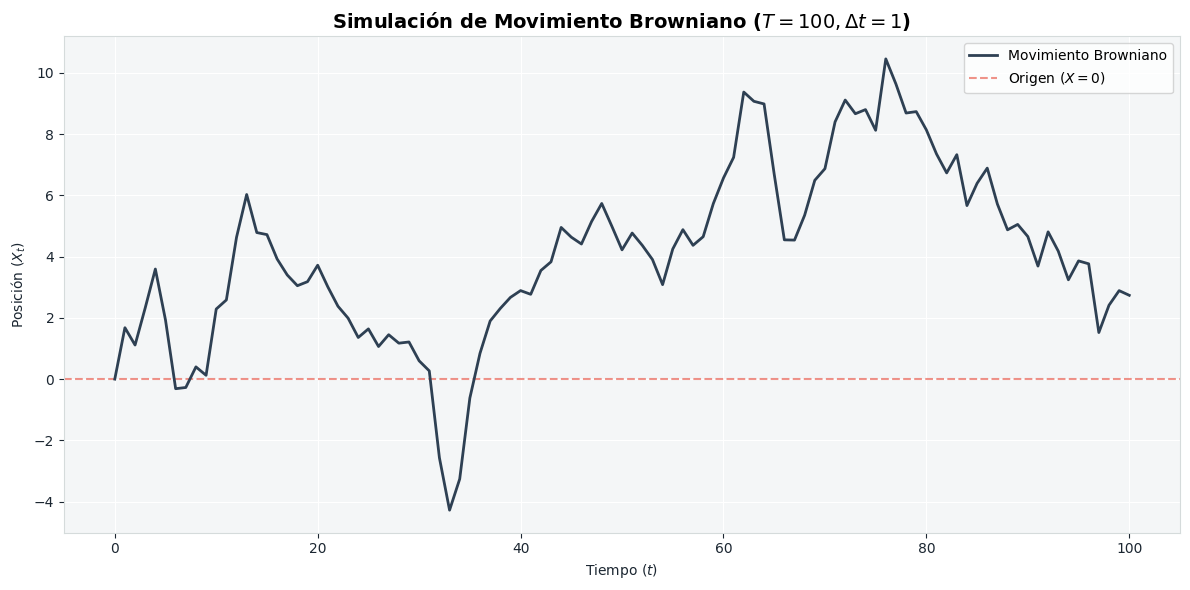

In [12]:
m=2**(31)-1
a=16807
b=0
x0=123456789


# --- Simulación del Movimiento Browniano ---
T = 100
dt = 1
n_pasos = int(T / dt)
x = 0
# Generación de saltos (Z)
u_lista = fUniformeN(x0, a, b, m, 200)
Z, z_sen = fBoxMuller(u_lista)

# Construcción de la trayectoria
incrementos = np.sqrt(dt) * Z
trayectoria = np.concatenate(([x], np.cumsum(incrementos)))
tiempo = np.linspace(0, T, n_pasos + 1)

plt.figure(figsize=(12, 6))

# Dibujamos la trayectoria
plt.plot(tiempo, trayectoria,
         label='Movimiento Browniano',
         color=PALETA['principal'],
         linewidth=2,
         zorder=3)

# Línea de origen (y=0)
plt.axhline(0, color=PALETA['teorico'], linestyle='--', alpha=0.6, label='Origen ($X=0$)')

# Título corregido con prefijo 'fr'
plt.title(fr'Simulación de Movimiento Browniano ($T={T}, \Delta t={dt}$)')
plt.xlabel(r'Tiempo ($t$)')
plt.ylabel(r'Posición ($X_t$)')

plt.legend(facecolor='white', framealpha=0.8)
plt.grid(True)
plt.tight_layout()
plt.show()

2. Generar 4 movimientos brownianos usando los valores de la distribución Normal generados mediante el seno y coseno del método de Box-Müller y también con variables antitéticas.

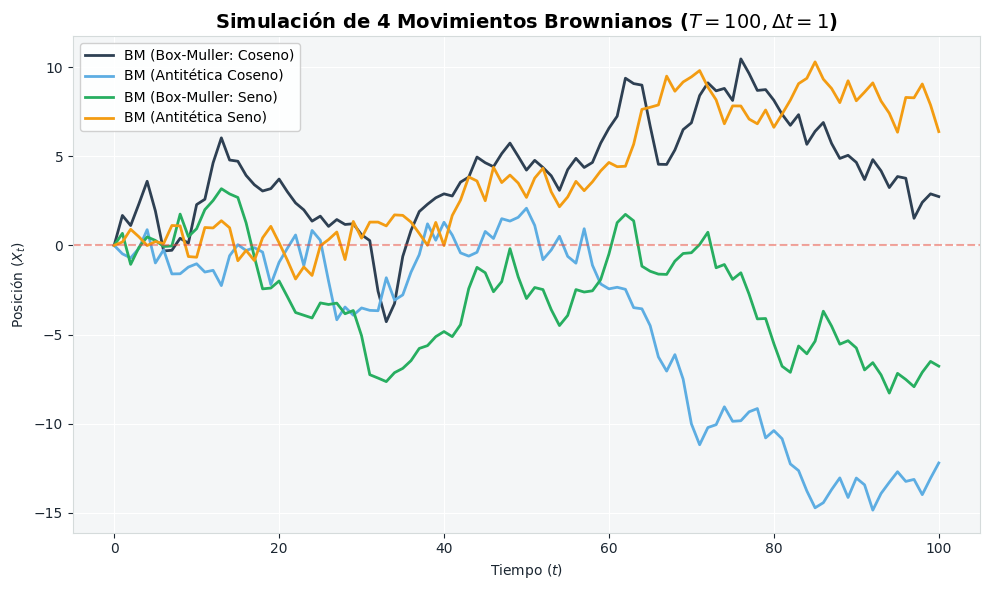

In [13]:
m=2**(31)-1
a=16807
b=0
x0=123456789


# Configuración de Simulación
T = 100
dt = 1
n_pasos = 100
x = 0

u_lista = fUniformeN(x0, a, b, m, 200)
z_cos, z_sen = fBoxMuller(u_lista)
z_cos_anti, z_sen_anti = fBoxMullerAntitetico(u_lista)

# Función auxiliar para construir el camino
def construir_camino(Z):
    pasos = np.sqrt(dt) * Z
    return np.cumsum(np.insert(pasos, 0, x))

caminos = [construir_camino(z) for z in [z_cos, z_sen, z_cos_anti, z_sen_anti]]
tiempo = np.arange(0, len(z_cos) + 1) * dt

# Visualización
plt.figure(figsize=(10, 6))

etiquetas = [
    'BM (Box-Muller: Coseno)',
    'BM (Antitética Coseno)',
    'BM (Box-Muller: Seno)',
    'BM (Antitética Seno)'
]

colores = [PALETA['principal'], PALETA['secundario'], '#27AE60', '#F39C12']


for i in range(4):
    plt.plot(tiempo, caminos[i], label=etiquetas[i], color=colores[i], lw=2)

# Línea de origen
plt.axhline(0, color=PALETA['teorico'], linestyle='--', alpha=0.5)

plt.title(fr'Simulación de 4 Movimientos Brownianos ($T={T}, \Delta t={dt}$)')
plt.xlabel(r'Tiempo ($t$)')
plt.ylabel(r'Posición ($X_t$)')

plt.legend(loc='upper left', facecolor='white', framealpha=0.9)
plt.grid(True)
plt.tight_layout()
plt.show()

3. Generar 4 movimientos brownianos usando los valores de la ditribución normal generados mediante el método de Marsaglia y también con variables antitéticas.

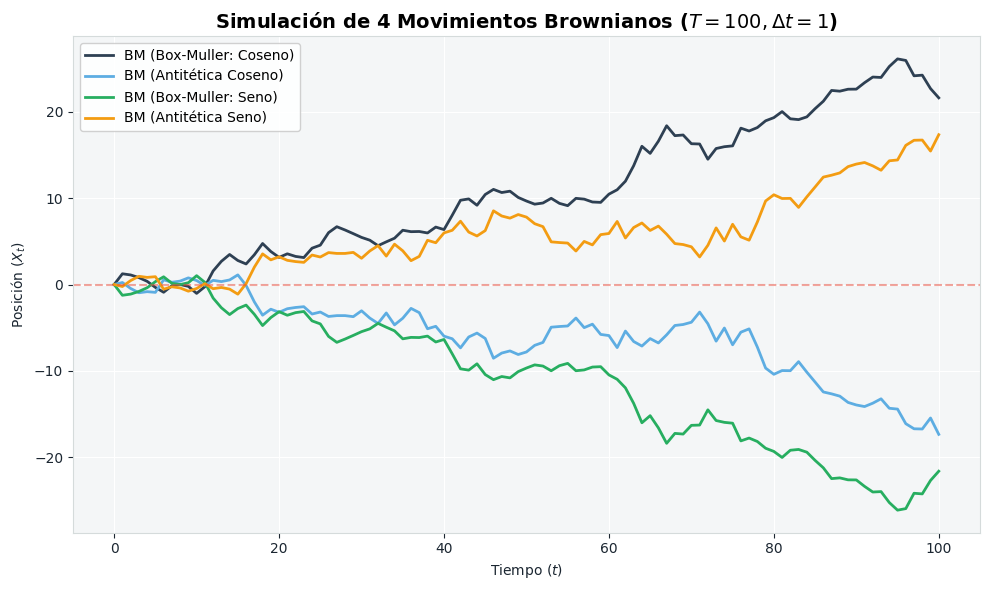

In [14]:
m=2**(31)-1
a=16807
b=0
x0=123456789


# Configuración de Simulación
T = 100
dt = 1
n_pasos = 100
x = 0

z_cos, z_sen, i1 = fMarsaglia(200, x0, a, b ,m)
z_cos_anti, z_sen_anti, i2 = fMarsagliaAntitetico(200, x0, a, b ,m)

# Función auxiliar para construir el camino
def construir_camino(Z):
    pasos = np.sqrt(dt) * Z
    return np.cumsum(np.insert(pasos, 0, x))

caminos = [construir_camino(z) for z in [z_cos, z_sen, z_cos_anti, z_sen_anti]]
tiempo = np.arange(0, len(z_cos) + 1) * dt

# Visualización
plt.figure(figsize=(10, 6))

etiquetas = [
    'BM (Box-Muller: Coseno)',
    'BM (Antitética Coseno)',
    'BM (Box-Muller: Seno)',
    'BM (Antitética Seno)'
]

colores = [PALETA['principal'], PALETA['secundario'], '#27AE60', '#F39C12']


for i in range(4):
    plt.plot(tiempo, caminos[i], label=etiquetas[i], color=colores[i], lw=2)

# Línea de origen
plt.axhline(0, color=PALETA['teorico'], linestyle='--', alpha=0.5)

plt.title(fr'Simulación de 4 Movimientos Brownianos ($T={T}, \Delta t={dt}$)')
plt.xlabel(r'Tiempo ($t$)')
plt.ylabel(r'Posición ($X_t$)')

plt.legend(loc='upper left', facecolor='white', framealpha=0.9)
plt.grid(True)
plt.tight_layout()
plt.show()

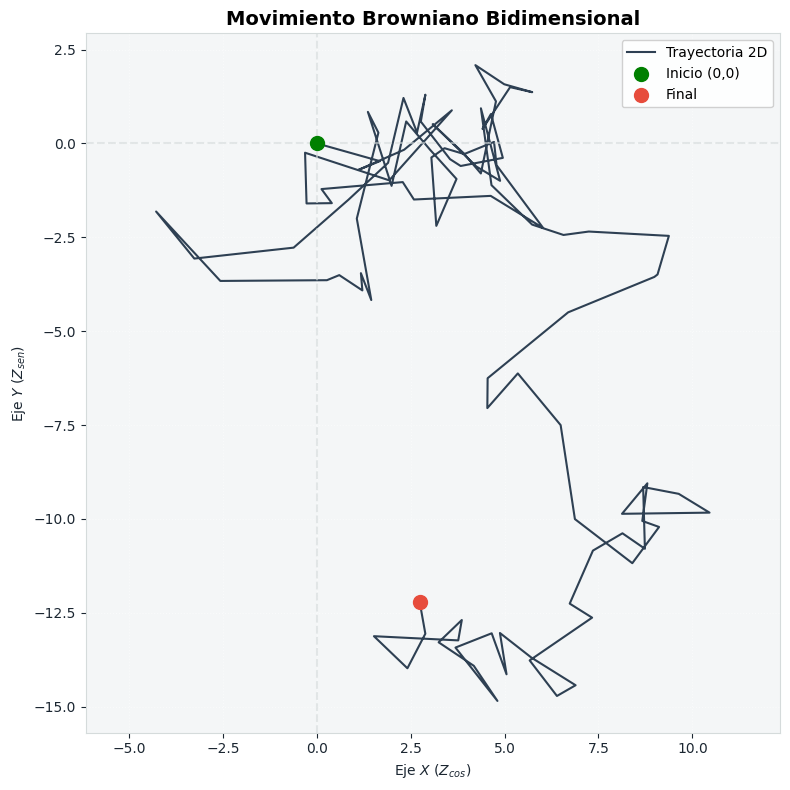

In [15]:
m=2**(31)-1
a=16807
b=0
x0=123456789

# Parámetros de la simulación
T = 100
dt = 1
n_pasos = 100


u_lista = fUniformeN(x0, a, b, m, 200)
z_cos, z_sen = fBoxMuller(u_lista)

# Construcción de las trayectorias por eje (partiendo de 0,0)
# Eje X: Normales calculadas con Coseno
camino_x = np.cumsum(np.insert(np.sqrt(dt) * z_cos, 0, 0))
# Eje Y: Normales calculadas con Seno
camino_y = np.cumsum(np.insert(np.sqrt(dt) * z_sen, 0, 0))

# 4. Visualización Bidimensional
plt.figure(figsize=(8, 8))

# Dibujamos la trayectoria en el plano XY
plt.plot(camino_x, camino_y,
         color=PALETA['principal'],
         lw=1.5,
         label='Trayectoria 2D',
         zorder=2)

# Resaltamos el punto de inicio y el punto final
plt.scatter(camino_x[0], camino_y[0], color='green', s=100, label='Inicio (0,0)', zorder=3)
plt.scatter(camino_x[-1], camino_y[-1], color=PALETA['teorico'], s=100, label='Final', zorder=3)

# Configuración de ejes y estilo
plt.axhline(0, color=PALETA['rejilla'], linestyle='--', alpha=0.6)
plt.axvline(0, color=PALETA['rejilla'], linestyle='--', alpha=0.6)

plt.title('Movimiento Browniano Bidimensional', fontsize=14, fontweight='bold')
plt.xlabel(r'Eje $X$ ($Z_{cos}$)')
plt.ylabel(r'Eje $Y$ ($Z_{sen}$)')

plt.legend(facecolor='white', framealpha=0.9)
plt.grid(True, linestyle=':', alpha=0.5)

# Forzamos que los ejes tengan la misma escala para ver el movimiento real
plt.axis('equal')
plt.tight_layout()
plt.show()